In [1]:
import jax.numpy as jnp
import neural_tangents as nt
from sklearn.model_selection import train_test_split
from jax.nn import one_hot
from jax import random, jit
import matplotlib.pyplot as plt
from neural_tangents import stax
from tqdm import tqdm

from utils.classificationDataGeneration import make_classification_dataset, demo_2d_examples, plot_2d_kde, plot_train_test_split, make_multitask_classification_datasets

In [2]:
def compute_empirical_ntk(apply_fn, params, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Create a function that computes the empirical NTK
    ntk_fn = nt.empirical_ntk_fn(apply_fn, trace_axes=(), vmap_axes=0, implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES)
   
    # Compute the kernel matrices
    ntk_train_train = ntk_fn(x_train, x_train, params)
    ntk_test_train  = ntk_fn(x_test, x_train, params)
    ntk_test_test   = ntk_fn(x_test, x_test, params)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Compute the kernel matrices, diagonal
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk', diagonal_axes=(0,))#, diagonal_outputs=False)
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')#, diagonal_outputs=False)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

In [ ]:
# Hyperparameters
num_class = 2
data_dim = 2
num_centers = 15 ** data_dim
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
num_tasks = 15
dim_hypercube = 1.0
centers_per_task = (num_centers // 19) - 1
regs = [10**(-i) for i in range(7)]+[0.0]  # Regularization sweep

# Storage
results = {reg_val: {"accs": [], "accs_std": []} for reg_val in regs}

pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points_per_task in pbar:
    pbar.set_description(f"P = {num_points_per_task}")

    for reg_value in regs:
        #print(f"Computing for reg={reg_value}")
        temp_accs = []

        for seed in range(num_tasks):
            # Generate multitask dataset (1 task per seed)
            ds_list = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,
                centers_per_task=centers_per_task,
                overlap=0.1,
                random_state=seed,
                reuse=False
            )

            ds = ds_list[0]  # Extract task
            X, y = ds['X'], ds['y']

            x_train, x_test, y_train, y_test = train_test_split(
                X, y, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

            # Build network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Infinite-width NTK
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand kernels for multiple outputs
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            # Gradient descent predictor
            predict_fn_inf = predict_fn = nt.predict.gradient_descent_mse(
                K_train_train_inf,
                y_train,
                diag_reg=reg_value,
                trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
            temp_accs.append(acc_inf)

        # Store mean/std
        results[reg_value]["accs"].append(jnp.mean(jnp.array(temp_accs)))
        results[reg_value]["accs_std"].append(jnp.std(jnp.array(temp_accs)))

In [ ]:
plt.figure(figsize=(7,5))
colors = cm.plasma(jnp.linspace(0, 1, len(regs)))

for i, reg_value in enumerate(regs):
    accs = results[reg_value]["accs"]
    accs_std = results[reg_value]["accs_std"]
    plt.errorbar(
        possible_num_points, accs, yerr=accs_std, 
        marker='o', color=colors[i], label=f'reg={reg_value}'
    )

plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of training points for different regularizations')
plt.grid(True)
plt.legend()
plt.show()


Demo: K=16, overlap=0.1 -> sigma=0.05825


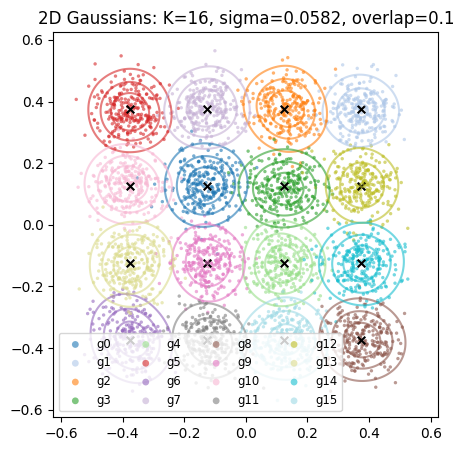

Classification Task: C=2


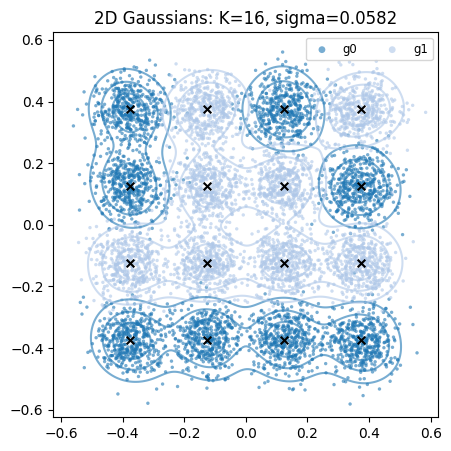

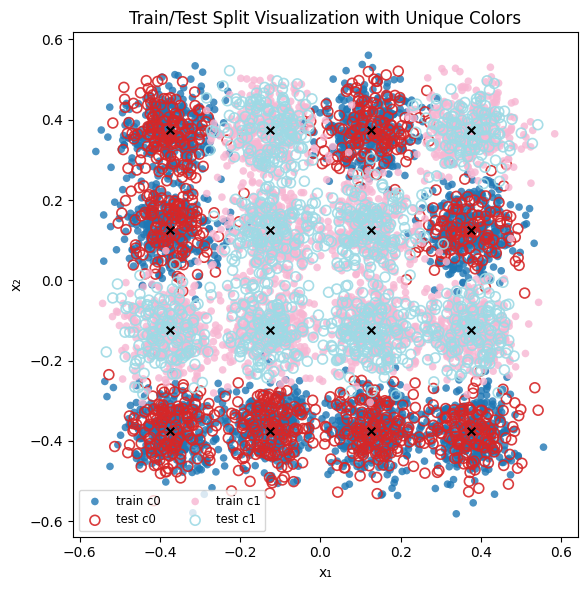

In [3]:
# Visualize demos (this will show 4 plots for Ks=(9,16) and overlaps=(0.2, 0.6))
demo_2d_examples(M=1.0, Ks=(16,), overlaps=(0.1,), samples_per_gaussian=250, random_state=42)

# Create a classification dataset
C=2  # Number of classes
N=2 # Number of dimensions
P=7000 # Number of total points

ds = make_classification_dataset(N=N, K=16, M=1.0, C=C, P=P, overlap=0.1, random_state=1)
X, y = ds['X'], ds['y']
assignment = ds['assignment']  # dict gaussian_idx -> class
centers = ds['centers']
sigma = ds['sigma']
print(f"Classification Task: C={C}")
_ = plot_2d_kde(centers, sigma, X, y)

# Let's train test split the data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
plot_train_test_split(x_train, y_train, x_test, y_test, centers, title="Train/Test Split Visualization with Unique Colors")

# Transform to jax arrays
x_train, x_test, y_trian, y_test = jnp.array(x_train), jnp.array(x_test), jnp.array(y_train), jnp.array(y_test)
y_train = one_hot(y_train, C).astype(jnp.float32)   # (n_train, C)
y_test  = one_hot(y_test,  C).astype(jnp.float32)   # (n_test, C)

In [4]:
# Parameters
widths = [2**i for i in range(15)][3:]
n_seeds = 10
C = 2  # Number of classes
key = random.PRNGKey(0)

# Regularization values
regs = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]

# Storage
results = {}  # Dictionary: reg -> dict(widths, mse, acc, mse_inf, acc_inf)

# Loop over regularizations
for reg in regs:
    print(f"Processing regularization = {reg}")
    
    errors_avg = []
    errors_std = []
    accuracies_avg = []
    accuracies_std = []
    
    Ks_train_train_dict = {}
    Ks_test_train_dict = {}

    # Loop over widths
    pbar = tqdm(widths, desc=f"Reg={reg}", leave=False)
    for width in pbar:
        pbar.set_description(f"Reg={reg}, Width={width}")
        
        mse_list = []
        acc_list = []
        keys = random.split(key, n_seeds)
        
        # Build network
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(width, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
        )
        apply_fn = jit(apply_fn)
        kernel_fn = jit(kernel_fn, static_argnames=('get'))
        
        for subkey in keys:
            _, params = init_fn(subkey, x_train.shape)
            
            # Compute empirical NTK
            ntk_dict = compute_empirical_ntk(apply_fn, params, x_train, x_test)
            K_train_train = ntk_dict["train_train"]
            K_test_train = ntk_dict["test_train"]
            
            # Gradient descent predictor
            predict_fn = nt.predict.gradient_descent_mse(
                K_train_train, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=True
            )
            
            fx_train_0 = apply_fn(params, x_train)
            fx_test_0 = apply_fn(params, x_test)
            
            _, preds_test = predict_fn(
                t=None, fx_train_0=fx_train_0, fx_test_0=fx_test_0,
                k_test_train=K_test_train
            )
            
            mse_list.append(float(jnp.mean((preds_test - y_test)**2)))
            pred_labels = jnp.argmax(preds_test, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_list.append(float(jnp.mean(pred_labels == true_labels)))
        
        # Average over seeds
        errors_avg.append(jnp.mean(jnp.array(mse_list)))
        errors_std.append(jnp.std(jnp.array(mse_list)))
        accuracies_avg.append(jnp.mean(jnp.array(acc_list)))
        accuracies_std.append(jnp.std(jnp.array(acc_list)))
        
        Ks_train_train_dict[width] = K_train_train
        Ks_test_train_dict[width] = K_test_train

    # Infinite-width NTK
    ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
    K_train_train_inf = ntk_dict_inf["train_train"]
    K_test_train_inf = ntk_dict_inf["test_train"]
    
    K_train_train_inf = jnp.stack([jnp.stack([K_train_train_inf if i==j else jnp.zeros_like(K_train_train_inf)
                                               for j in range(C)], axis=-1)
                                    for i in range(C)], axis=-2)

    K_test_train_inf = jnp.stack([jnp.stack([K_test_train_inf if i==j else jnp.zeros_like(K_test_train_inf)
                                             for j in range(C)], axis=-1)
                                  for i in range(C)], axis=-2)

    predict_fn_inf = nt.predict.gradient_descent_mse(
        K_train_train_inf, y_train,
        diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=True
    )
    
    fx_train_0_inf = jnp.zeros_like(y_train)
    fx_test_0_inf = jnp.zeros_like(y_test)
    
    _, preds_test_inf = predict_fn_inf(
        t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
        k_test_train=K_test_train_inf
    )
    
    mse_inf = float(jnp.mean((preds_test_inf - y_test)**2))
    pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
    acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
    
    # Save results
    results[reg] = {
        "widths": widths,
        "mse_avg": errors_avg,
        "mse_std": errors_std,
        "acc_avg": accuracies_avg,
        "acc_std": accuracies_std,
        "mse_inf": mse_inf,
        "acc_inf": acc_inf
    }

Processing regularization = 1e-05


Processing regularization = 0.0001


Processing regularization = 0.001


Processing regularization = 0.01


Processing regularization = 0.1


Processing regularization = 1.0


Processing regularization = 10.0


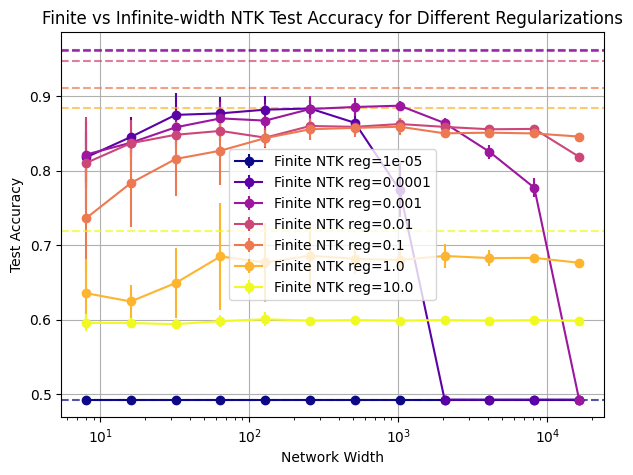

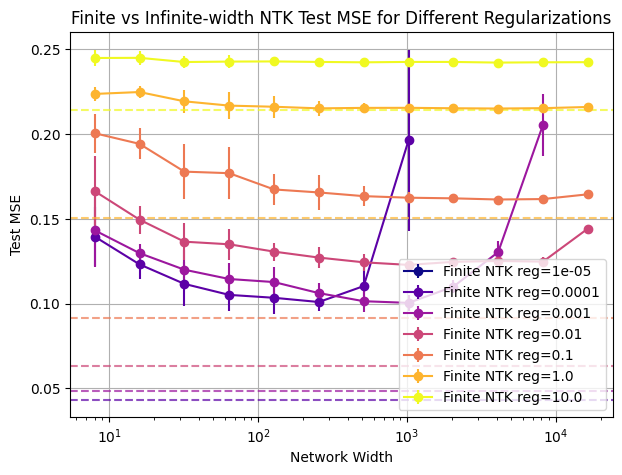

In [5]:
# Plot Test Accuracy vs Width for all regs
plt.figure(figsize=(7,5))
colors = plt.cm.plasma(jnp.linspace(0,1,len(regs)))
for i, reg in enumerate(regs):
    plt.errorbar(results[reg]["widths"], results[reg]["acc_avg"], yerr=results[reg]["acc_std"],
                 marker='o', color=colors[i], label=f'Finite NTK reg={reg}')
    plt.axhline(y=results[reg]["acc_inf"], color=colors[i], linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width')
plt.ylabel('Test Accuracy')
plt.title('Finite vs Infinite-width NTK Test Accuracy for Different Regularizations')
plt.legend()
plt.grid(True)
plt.show()

# Plot Test MSE vs Width for all regs
plt.figure(figsize=(7,5))
for i, reg in enumerate(regs):
    plt.errorbar(results[reg]["widths"], results[reg]["mse_avg"], yerr=results[reg]["mse_std"],
                 marker='o', color=colors[i], label=f'Finite NTK reg={reg}')
    plt.axhline(y=results[reg]["mse_inf"], color=colors[i], linestyle='--', alpha=0.7)

plt.xscale('log')
plt.xlabel('Network Width')
plt.ylabel('Test MSE')
plt.title('Finite vs Infinite-width NTK Test MSE for Different Regularizations')
plt.legend()
plt.grid(True)
plt.show()


Look between 1 and 0.001 for abs reg